1. Data Loading

In [3]:
from medmnist import BreastMNIST

dataset = BreastMNIST(split="train", download=True)

In [4]:
import torchvision.transforms as transforms
from medmnist import BreastMNIST

#we define the convertion of the images from the dataset to tensors
data_transform = transforms.Compose([transforms.ToTensor()])

#download and load the datasets with the tensor transformation applied
train_dataset = BreastMNIST(split="train", transform=data_transform, download=True)
val_dataset = BreastMNIST(split="val", transform=data_transform, download=True)
test_dataset = BreastMNIST(split="test", transform=data_transform, download=True)

Text(0.5, 1.0, 'Label: 1')

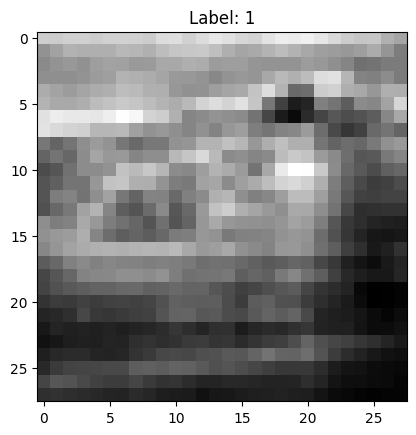

In [5]:
import matplotlib.pyplot as plt

#extract the image 67 from the training dataset
img, label = train_dataset[67]

plt.imshow(img.squeeze(), cmap="gray")

plt.title(f"Label: {label[0]}")
#we will get a lable:0 if its a benign tumor and 1 if its a malignant

In [6]:
from torch.utils.data import DataLoader
import torch

torch.manual_seed(67)

#we will give the model 32 at once each time
b_size = 32

#creating the datasets
train_loader = DataLoader(dataset=train_dataset, batch_size=b_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=b_size, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=b_size, shuffle=False)

print(f"number of batches for training: {len(train_loader)}")

number of batches for training: 18


In [7]:
import torch.nn as nn

class LogisticRegression(nn.Module):
    def __init__(self):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(28*28, 1)
    def forward(self,x):
        x = x.view(-1, 28*28)

        output = self.linear(x)

        #standarize with sigmoid to get a probabilty as 0-1
        prob = torch.sigmoid(output)
        return prob

model = LogisticRegression()


In [13]:
#first we define the loss function and optimizer

criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01) #Stochastic Gradiend Descent

num_k = 10
lossL = []

#Training Loop
for k in range(num_k):
    k_loss=0
    for i, (images,labels) in enumerate(train_loader):
        #convert labels to float to match the model output type
        labels = labels.float()
        
        #predictions
        outputs = model(images)

        #calculate the loss
        loss = criterion(outputs, labels)

        #pass and optimize
        optimizer.zero_grad() #clear old gradients
        loss.backward()  #compute new gradients
        optimizer.step() #update weights

        k_loss += loss.item()

    average_loss = k_loss / len(train_loader)
    lossL.append(average_loss)
    print(f"k [{k+1}/{num_k}], Loss: {average_loss:.4f}")

k [1/10], Loss: 0.5121
k [2/10], Loss: 0.5141
k [3/10], Loss: 0.5269
k [4/10], Loss: 0.5148
k [5/10], Loss: 0.5114
k [6/10], Loss: 0.4848
k [7/10], Loss: 0.4937
k [8/10], Loss: 0.4988
k [9/10], Loss: 0.4959
k [10/10], Loss: 0.5141


Final Test Accuracy: 78.21%


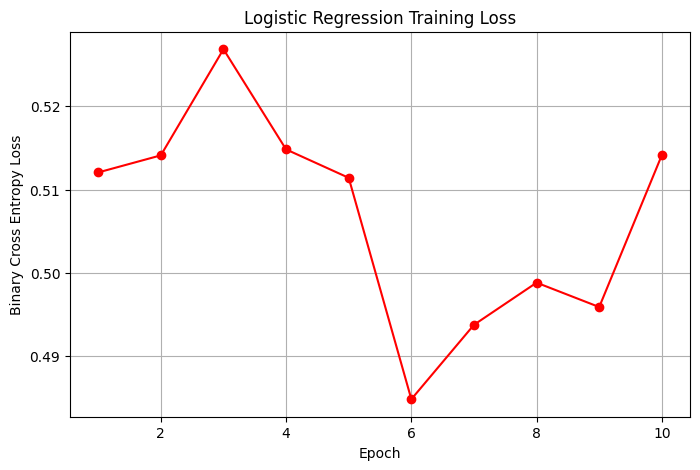

In [15]:
#evaluate the model
model.eval()
correct = 0
total = 0

#disable gradient calculation for testing
with torch.no_grad():
    for images, labels in test_loader:
        labels = labels.float()
        outputs = model(images)
        
        #if probability > 0.5, predict 1 (malignant), else predict 0 (benign)
        predicted = (outputs >= 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Final Test Accuracy: {accuracy:.2f}%")

# Plot the training loss curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_k+ 1), lossL, marker="o", color="red")
plt.title("Logistic Regression Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.grid(True)
plt.show()